In [1]:
!pip install ultralytics==8.3.148 -q
!pip install albumentations==1.4.0 -q
!pip install seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 3.4 MB/s eta 0:00:00


In [2]:
import os
import cv2
import yaml
import torch
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ultralytics import YOLO

warnings.filterwarnings("ignore")

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

# Fix Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("Seed Fixed:", SEED)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch Version: 2.10.0+cu128
CUDA Available: True
Seed Fixed: 42


In [3]:
from sklearn.model_selection import train_test_split
import shutil
from glob import glob

# Dataset Paths
IMAGE_DIR = "/kaggle/input/datasets/makmudulhasanrabbi/road-surface-damage-datasetrsdd/data/images"
LABEL_DIR = "/kaggle/input/datasets/makmudulhasanrabbi/road-surface-damage-datasetrsdd/data/labels-YOLO"

# Output
OUTPUT_DIR = "/kaggle/working/road_damage_dataset"

# Create YOLO Folder Structure
for split in ["train", "val", "test"]:
    os.makedirs(f"{OUTPUT_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/labels/{split}", exist_ok=True)

# Get Image Files
image_files = []
for ext in ["*.jpg", "*.png", "*.jpeg"]:
    image_files.extend(glob(os.path.join(IMAGE_DIR, ext)))

print("Total Images:", len(image_files))

# 70% / 15% / 15%
train_files, temp_files = train_test_split(
    image_files, test_size=0.30, random_state=42, shuffle=True
)
val_files, test_files = train_test_split(
    temp_files, test_size=0.50, random_state=42, shuffle=True
)

print(f"Train: {len(train_files)}")
print(f"Validation: {len(val_files)}")
print(f"Test: {len(test_files)}")

# Copy Files
def copy_files(file_list, split_name):
    for img_path in file_list:
        file_name = os.path.basename(img_path)
        label_name = os.path.splitext(file_name)[0] + ".txt"
        label_path = os.path.join(LABEL_DIR, label_name)

        shutil.copy(img_path, os.path.join(OUTPUT_DIR, f"images/{split_name}", file_name))

        if os.path.exists(label_path):
            shutil.copy(label_path, os.path.join(OUTPUT_DIR, f"labels/{split_name}", label_name))

copy_files(train_files, "train")
copy_files(val_files, "val")
copy_files(test_files, "test")

print("Dataset split completed successfully")

Total Images: 2009
Train: 1406
Validation: 301
Test: 302
Dataset split completed successfully


In [4]:
DATASET_ROOT = "/kaggle/working/road_damage_dataset"

CLASS_NAMES = {
    0: "pothole",
    1: "crack",
    2: "manhole",
}

data_yaml = {
    "path": DATASET_ROOT,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": CLASS_NAMES
}

with open("data.yaml", "w") as f:
    yaml.dump(data_yaml, f)

print("data.yaml created successfully")

data.yaml created successfully


In [5]:
import torch
import torch.nn as nn


class ChannelAttention(nn.Module):
    def __init__(self, c1, ratio=16):
        super().__init__()

        hidden = max(c1 // ratio, 8)

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(c1, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, c1, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()

        self.conv = nn.Conv2d(
            2, 1, kernel_size,
            padding=kernel_size // 2,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(x))


class CBAM(nn.Module):
    def __init__(self, c1, c2=None):
        super().__init__()

        self.ca = ChannelAttention(c1)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = self.ca(x) * x
        x = self.sa(x) * x
        return x

In [6]:
import sys

TASKS_FILE = "/usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py"

with open(TASKS_FILE, "r") as f:
    txt = f.read()

if "elif m is CBAM:" not in txt:
    # Robust line-by-line search: find the "else:" branch followed by "c2 = ch[f]"
    # inside parse_model, and insert our CBAM elif before it
    lines = txt.split('\n')
    inserted = False
    for i in range(len(lines) - 1):
        if lines[i].strip() == 'else:' and 'c2 = ch[f]' in lines[i + 1]:
            indent = lines[i][:len(lines[i]) - len(lines[i].lstrip())]
            cbam_block = [
                f"{indent}elif m is CBAM:",
                f"{indent}    c1 = ch[f]",
                f"{indent}    c2 = c1",
                f"{indent}    args = [c1]",
                "",
            ]
            lines = lines[:i] + cbam_block + lines[i:]
            inserted = True
            break

    if inserted:
        with open(TASKS_FILE, "w") as f:
            f.write('\n'.join(lines))
        print("CBAM parser patched successfully")
    else:
        print("ERROR: Could not find insertion point in parse_model!")
else:
    print("CBAM parser already patched")

# CRITICAL: Purge all cached ultralytics modules so Python
# re-imports them from the patched files on disk.
# Without this, the in-memory parse_model still has the OLD code.
mods_to_remove = [k for k in sys.modules if 'ultralytics' in k]
for mod_name in mods_to_remove:
    del sys.modules[mod_name]
print(f"Purged {len(mods_to_remove)} ultralytics modules from cache")

CBAM parser patched successfully
Purged 90 ultralytics modules from cache


In [7]:
from ultralytics import YOLO
import ultralytics.nn.tasks as tasks
import ultralytics.nn.modules as modules

tasks.CBAM = CBAM
tasks.ChannelAttention = ChannelAttention
tasks.SpatialAttention = SpatialAttention
modules.CBAM = CBAM

# Verify the patch is active
import inspect
src = inspect.getsource(tasks.parse_model)
if "elif m is CBAM:" in src:
    print("CBAM Registered + parse_model patch VERIFIED active")
else:
    print("WARNING: parse_model patch NOT found in memory!")

print("CBAM Registered")

CBAM Registered + parse_model patch VERIFIED active
CBAM Registered


In [8]:
cbam_yaml = r"""
nc: 3

scales:
  s: [0.33, 0.50, 1024]

backbone:

  - [-1, 1, Conv, [64, 3, 2]]

  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 3, C2f, [128, True]]

  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 6, C2f, [256, True]]
  - [-1, 1, CBAM, []]

  - [-1, 1, Conv, [512, 3, 2]]
  - [-1, 6, C2f, [512, True]]
  - [-1, 1, CBAM, []]

  - [-1, 1, Conv, [1024, 3, 2]]
  - [-1, 3, C2f, [1024, True]]
  - [-1, 1, CBAM, []]

  - [-1, 1, SPPF, [1024, 5]]

head:

  - [-1, 1, nn.Upsample, [None, 2, nearest]]
  - [[-1, 8], 1, Concat, [1]]
  - [-1, 3, C2f, [512]]

  - [-1, 1, nn.Upsample, [None, 2, nearest]]
  - [[-1, 5], 1, Concat, [1]]
  - [-1, 3, C2f, [256]]

  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 15], 1, Concat, [1]]
  - [-1, 3, C2f, [512]]

  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 12], 1, Concat, [1]]
  - [-1, 3, C2f, [1024]]

  - [[18, 21, 24], 1, Detect, [nc]]
"""

with open("yolov8s_cbam.yaml", "w") as f:
    f.write(cbam_yaml)

print("YOLOv8s+CBAM YAML Saved")

YOLOv8s+CBAM YAML Saved


In [9]:
from ultralytics import YOLO

model = YOLO("yolov8s_cbam.yaml")
model.load("yolov8s.pt")

print("Pretrained weights loaded")

results = model.train(
    data="data.yaml",

    epochs=120,
    imgsz=1024,
    batch=12,
    device=0,

    optimizer="AdamW",
    lr0=0.0005,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=8,
    cos_lr=True,
    patience=50,

    mosaic=1.0,
    close_mosaic=15,
    mixup=0.15,
    copy_paste=0.1,
    degrees=5.0,
    translate=0.2,
    scale=0.5,
    fliplr=0.5,
    flipud=0.1,
    erasing=0.2,

    hsv_h=0.02,
    hsv_s=0.7,
    hsv_v=0.4,

    cache=True,
    amp=True,
    workers=4,
    deterministic=False,

    project="RoadDamage",
    name="YOLOv8s_CBAM",
    exist_ok=True
)

print("Training Completed")

100%|██████████| 21.5M/21.5M [00:00<00:00, 159MB/s]


Transferred 97/364 items from pretrained weights
Transferred 97/364 items from pretrained weights
Pretrained weights loaded
New https://pypi.org/project/ultralytics/8.4.117 available 😃 Update with 'pip install -U ultralytics'
New https://pypi.org/project/ultralytics/8.4.117 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.148 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Ultralytics 8.3.148 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=15, cls=0.5, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=5.0, deterministic=False, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=120, erasing=0.2, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02

100%|██████████| 755k/755k [00:00<00:00, 16.9MB/s]



                   from  n    params  module                                       arguments                     

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64

100%|██████████| 5.35M/5.35M [00:00<00:00, 67.9MB/s]


...

    120/120      7.12G      1.287     0.9391      1.392          5       1024: 100%|██████████| 118/118 [00:54<00:00,  2.18it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:03<00:00,  4.06it/s]

                   all        301        715      0.586      0.532      0.521       0.22
                   all        301        715      0.586      0.532      0.521       0.22



120 epochs completed in 1.940 hours.

120 epochs completed in 1.940 hours.
Optimizer stripped from RoadDamage/YOLOv8s_CBAM/weights/last.pt, 22.6MB
Optimizer stripped from RoadDamage/YOLOv8s_CBAM/weights/last.pt, 22.6MB
Optimizer stripped from RoadDamage/YOLOv8s_CBAM/weights/best.pt, 22.6MB
Optimizer stripped from RoadDamage/YOLOv8s_CBAM/weights/best.pt, 22.6MB

Validating RoadDamage/YOLOv8s_CBAM/weights/best.pt...

Validating RoadDamage/YOLOv8s_CBAM/weights/best.pt...
Ultralytics 8.3.148 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Ultralytics 8.3.148 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8s_cbam summary (fused): 96 layers, 11,170,047 parameters, 0 gradients, 28.5 GFLOPs
YOLOv8s_cbam summary (fused): 96 layers, 11,170,047 parameters, 0 gradients, 28.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:04<00:00,  2.97it/s]


                   all        301        715      0.624      0.539      0.554      0.236
                   all        301        715      0.624      0.539      0.554      0.236
               pothole        115        185      0.558      0.402       0.46      0.181
               pothole        115        185      0.558      0.402       0.46      0.181
                 crack        205        383      0.475      0.411      0.378      0.121
                 crack        205        383      0.475      0.411      0.378      0.121
               manhole        117        147      0.841      0.803      0.826      0.407
               manhole        117        147      0.841      0.803      0.826      0.407
Speed: 1.1ms preprocess, 7.2ms inference, 0.0ms loss, 1.2ms postprocess per image
Speed: 1.1ms preprocess, 7.2ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to RoadDamage/YOLOv8s_CBAM
Results saved to RoadDamage/YOLOv8s_CBAM
Training Completed


In [10]:
metrics = model.val()
print(metrics)

Ultralytics 8.3.148 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Ultralytics 8.3.148 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8s_cbam summary (fused): 96 layers, 11,170,047 parameters, 0 gradients, 28.5 GFLOPs
YOLOv8s_cbam summary (fused): 96 layers, 11,170,047 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2055.7±409.4 MB/s, size: 87.5 KB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2055.7±409.4 MB/s, size: 87.5 KB)


val: Scanning /kaggle/working/road_damage_dataset/labels/val.cache... 301 images, 0 backgrounds, 0 corrupt: 100%|██████████| 301/301 [00:00<?, ?it/s]
val: Caching images (0.5GB RAM): 100%|██████████| 301/301 [00:00<00:00, 568.31it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:06<00:00,  4.09it/s]


                   all        301        715       0.62      0.541      0.555      0.235
                   all        301        715       0.62      0.541      0.555      0.235
               pothole        115        185      0.558      0.411      0.461       0.18
               pothole        115        185      0.558      0.411      0.461       0.18
                 crack        205        383      0.473       0.41      0.378      0.121
                 crack        205        383      0.473       0.41      0.378      0.121
               manhole        117        147      0.829      0.803      0.826      0.405
               manhole        117        147      0.829      0.803      0.826      0.405
Speed: 1.3ms preprocess, 15.4ms inference, 0.0ms loss, 0.8ms postprocess per image
Speed: 1.3ms preprocess, 15.4ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to RoadDamage/YOLOv8s_CBAM
Results saved to RoadDamage/YOLOv8s_CBAM
ultralytics.utils.metrics.DetMetrics obj

In [11]:
results = model.predict(
    source=os.path.join(DATASET_ROOT, "images/test"),
    save=True,
    conf=0.25
)
print("Prediction Completed")



image 1/302 /kaggle/working/road_damage_dataset/images/test/20250219_164838.jpg: 576x1024 1 pothole, 3 cracks, 3 manholes, 49.6ms
image 1/302 /kaggle/working/road_damage_dataset/images/test/20250219_164838.jpg: 576x1024 1 pothole, 3 cracks, 3 manholes, 49.6ms
image 2/302 /kaggle/working/road_damage_dataset/images/test/20250219_165042.jpg: 576x1024 3 potholes, 2 cracks, 22.5ms
image 2/302 /kaggle/working/road_damage_dataset/images/test/20250219_165042.jpg: 576x1024 3 potholes, 2 cracks, 22.5ms
image 3/302 /kaggle/working/road_damage_dataset/images/test/20250219_165100.jpg: 576x1024 2 potholes, 2 cracks, 22.5ms
image 3/302 /kaggle/working/road_damage_dataset/images/test/20250219_165100.jpg: 576x1024 2 potholes, 2 cracks, 22.5ms
image 4/302 /kaggle/working/road_damage_dataset/images/test/20250219_165339.jpg: 576x1024 1 pothole, 22.5ms
image 4/302 /kaggle/working/road_damage_dataset/images/test/20250219_165339.jpg: 576x1024 1 pothole, 22.5ms
image 5/302 /kaggle/working/road_damage_datase

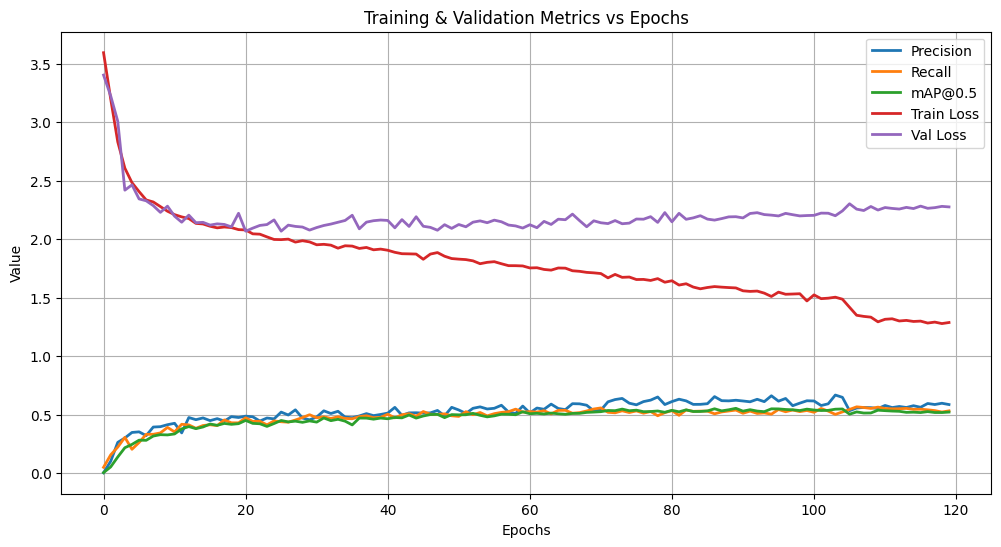

In [12]:
results_csv = "/kaggle/working/RoadDamage/YOLOv8s_CBAM/results.csv"
df = pd.read_csv(results_csv)

plt.figure(figsize=(12, 6))

plt.plot(df['metrics/precision(B)'], label='Precision', linewidth=2)
plt.plot(df['metrics/recall(B)'], label='Recall', linewidth=2)
plt.plot(df['metrics/mAP50(B)'], label='mAP@0.5', linewidth=2)
plt.plot(df['train/box_loss'], label='Train Loss', linewidth=2)
plt.plot(df['val/box_loss'], label='Val Loss', linewidth=2)

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training & Validation Metrics vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import math
import matplotlib.image as mpimg

folder_path = "/kaggle/working/RoadDamage/YOLOv8s_CBAM"

image_files = [
    f for f in os.listdir(folder_path)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]
image_files.sort()

print("Total Images Found:", len(image_files))

cols = 2
rows = math.ceil(len(image_files) / cols)

plt.figure(figsize=(15, rows * 5))
for idx, image_name in enumerate(image_files):
    image_path = os.path.join(folder_path, image_name)
    img = mpimg.imread(image_path)
    plt.subplot(rows, cols, idx + 1)
    plt.imshow(img)
    plt.title(image_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Total Images Found: 323


Ultralytics 8.3.148 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Ultralytics 8.3.148 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8s_cbam summary (fused): 96 layers, 11,170,047 parameters, 0 gradients, 28.5 GFLOPs
YOLOv8s_cbam summary (fused): 96 layers, 11,170,047 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2314.8±425.3 MB/s, size: 91.6 KB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2314.8±425.3 MB/s, size: 91.6 KB)


val: Scanning /kaggle/working/road_damage_dataset/labels/val.cache... 301 images, 0 backgrounds, 0 corrupt: 100%|██████████| 301/301 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 19/19 [00:06<00:00,  3.10it/s]


                   all        301        715       0.62      0.541      0.555      0.235
                   all        301        715       0.62      0.541      0.555      0.235
               pothole        115        185      0.558      0.411      0.461       0.18
               pothole        115        185      0.558      0.411      0.461       0.18
                 crack        205        383      0.473       0.41      0.378      0.121
                 crack        205        383      0.473       0.41      0.378      0.121
               manhole        117        147      0.829      0.803      0.826      0.405
               manhole        117        147      0.829      0.803      0.826      0.405
Speed: 1.4ms preprocess, 12.9ms inference, 0.0ms loss, 1.5ms postprocess per image
Speed: 1.4ms preprocess, 12.9ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs/detect/val2
Results saved to runs/detect/val2

Per-Class AP
pothole   : 0.1803
crack     : 0.1214
ma

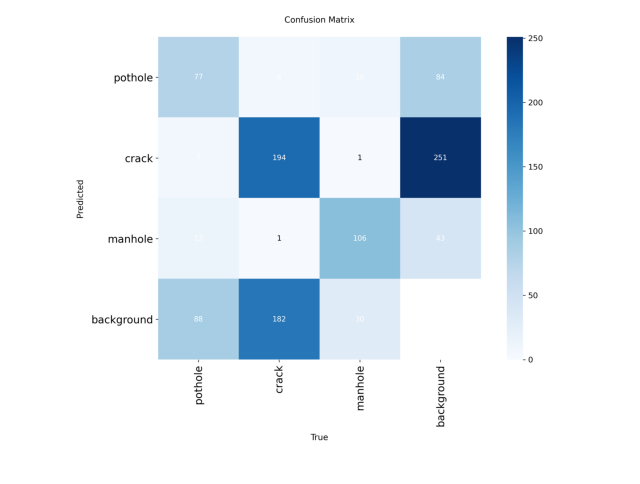

Precision        : 0.6201
Recall           : 0.5412
F1 Score         : 0.5779
mAP@0.5          : 0.5551
mAP@0.5:0.95     : 0.2355
FPS              : 62.38
Latency          : 16.03 ms
Total Parameters : 11,170,047
Trainable Params : 0
YOLOv8s_cbam summary (fused): 96 layers, 11,170,047 parameters, 0 gradients, 28.5 GFLOPs
YOLOv8s_cbam summary (fused): 96 layers, 11,170,047 parameters, 0 gradients, 28.5 GFLOPs


(96, 11170047, 0, 28.5110864)

In [15]:
from ultralytics import YOLO
from ultralytics.utils.torch_utils import model_info
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import time
import os

best_model = "/kaggle/working/RoadDamage/YOLOv8s_CBAM/weights/best.pt"
model = YOLO(best_model)

results = model.val(plots=True)

precision = results.box.mp
recall = results.box.mr
map50 = results.box.map50
map5095 = results.box.map
f1 = 2 * precision * recall / (precision + recall + 1e-16)

print("\nPer-Class AP")
for i, ap in enumerate(results.box.maps):
    print(f"{model.names[i]:10s}: {ap:.4f}")

total_params = sum(p.numel() for p in model.model.parameters())
trainable_params = sum(
    p.numel() for p in model.model.parameters()
    if p.requires_grad
)

image_path = "/kaggle/working/road_damage_dataset/images/val/20250219_164714.jpg"
image = cv2.imread(image_path)

for _ in range(20):
    model.predict(image, verbose=False)

runs = 100

start = time.time()
for _ in range(runs):
    model.predict(image, verbose=False)
end = time.time()

fps = runs / (end - start)
latency = 1000 / fps

cm_path = os.path.join(results.save_dir, "confusion_matrix.png")

if os.path.exists(cm_path):
    plt.figure(figsize=(8, 8))
    plt.imshow(Image.open(cm_path))
    plt.axis("off")
    plt.show()

print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1 Score         : {f1:.4f}")
print(f"mAP@0.5          : {map50:.4f}")
print(f"mAP@0.5:0.95     : {map5095:.4f}")
print(f"FPS              : {fps:.2f}")
print(f"Latency          : {latency:.2f} ms")
print(f"Total Parameters : {total_params:,}")
print(f"Trainable Params : {trainable_params:,}")

model_info(model.model)

In [16]:
import os
import zipfile

# Notebook: yolov8s-p2-head  (YOLOv8s + P2 Head)

base = "/kaggle/working"

items = [       # train output (YOLOv8s_P2_Balanced)
    "RoadDamage",             # runs/detect/... + predict outputs
    "yolov8s_cbam.yaml",  # model config
    "data.yaml",
    "yolov8s.pt"
]

zip_path = "/kaggle/working/yolov8s_cbam_outputs.zip"

print("Creating ZIP...")
print("Destination:", zip_path)

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=6
) as z:

    for item in items:

        path = os.path.join(base, item)

        if not os.path.exists(path):
            print("SKIP - not found:", item)
            continue

        if os.path.isfile(path):
            z.write(path, arcname=item)
            print("Added:", item)

        elif os.path.isdir(path):
            for root, dirs, files in os.walk(path):
                for file in files:
                    full_path = os.path.join(root, file)
                    arcname = os.path.relpath(full_path, base)

                    z.write(full_path, arcname=arcname)

            print("Added folder:", item)

print("\nZIP CREATED SUCCESSFULLY!")

size = os.path.getsize(zip_path) / (1024**3)

print(f"ZIP size: {size:.3f} GB")
print("Path:", zip_path)

Creating ZIP...
Destination: /kaggle/working/yolov8s_cbam_outputs.zip
Added folder: RoadDamage
Added: yolov8s_cbam.yaml
Added: data.yaml
Added: yolov8s.pt

ZIP CREATED SUCCESSFULLY!
ZIP size: 0.091 GB
Path: /kaggle/working/yolov8s_cbam_outputs.zip
